In [1]:
import geopandas as gpd
import geonamescache
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
from numpy.random import choice
import random
import datetime
from shapely import Point
from datetime import datetime, timedelta

import warnings

In [2]:
area_clusters = pd.read_csv("/home/mohamed/Mohamed/Vodafone_project/projects/app/files/anamoly_detection_files/areas_clusters.csv")

In [3]:
area_clusters = area_clusters.rename(columns={"area_id":"SSEC_CODE"})
area_clusters.head()

,SSEC_CODE,population_density,cluster
0,10101,0.234255,0
1,10102,0.234255,0
2,10103,0.234255,0
3,10104,0.066129,16
4,10105,0.234255,0


In [4]:
SHAPEFILE = "/home/mohamed/Mohamed/Vodafone_project/all_egypt_map_shpfile/shp_output_names/Shyakha_Village/Shyakha_Village.shp"
areas_gdf = gpd.GeoDataFrame.from_file(SHAPEFILE)


In [5]:
areas_gdf.head()

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183..."
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578..."
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548..."
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30..."
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30..."


In [6]:
areas_gdf_with_cluster = pd.merge(areas_gdf, area_clusters, on='SSEC_CODE', how='inner')

In [7]:
areas_gdf_with_cluster

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population_density,cluster
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",0.123337,11
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",0.019472,9
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",0.044902,23
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",0.030826,18
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",0.019472,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",0.212810,20
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",0.076415,6
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",0.234255,0
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",0.040368,7


In [8]:
qisms_group_with_cluster = areas_gdf_with_cluster.groupby(["SEC_CODE", "cluster"])["SEC_CODE"].count().to_frame().rename(columns={"SEC_CODE":"number_of_clusters"})

In [9]:
qisms_group_with_cluster

number_of_clusters
SEC_CODE cluster                    
101      0                         4
         16                        1
102      0                         6
         2                         3
         21                        1
...                              ...
3506     9                         1
3507     0                         1
         9                         2
3508     9                         1
3599     9                         6

[1942 rows x 1 columns]

In [10]:
clusters_tss = []
for curr_cluster in range(27):
    clusters_tss.append(pd.read_csv(f"/home/mohamed/Mohamed/Vodafone_project/projects/app/visualization/area_clusters_dir/counts_{curr_cluster}.csv", names=["time", "count"]))


In [11]:
qisms_group_with_cluster.reset_index(inplace=True)
qisms_group_with_cluster

,SEC_CODE,cluster,number_of_clusters
0,101,0,4
1,101,16,1
2,102,0,6
3,102,2,3
4,102,21,1
...,...,...,...
1937,3506,9,1
1938,3507,0,1
1939,3507,9,2
1940,3508,9,1


In [12]:
for x in qisms_group_with_cluster[qisms_group_with_cluster["SEC_CODE"] == 1].iterrows():
    # print(x)
    print(x[1].cluster)

In [13]:
len(qisms_group_with_cluster["SEC_CODE"].unique())

374

In [14]:
time_column = clusters_tss[0]["time"]

In [15]:
qisms_dfs = {}
for i, SEC_CODE in enumerate(qisms_group_with_cluster["SEC_CODE"].unique()):
    print(i, SEC_CODE)
    curr_ts_data = pd.DataFrame({
        "time": time_column,
        "count": np.zeros((len(time_column)))
    })
    for x in qisms_group_with_cluster[qisms_group_with_cluster["SEC_CODE"] == SEC_CODE].iterrows():
        # print(x[1].cluster)
        curr_ts_data["count"] += clusters_tss[x[1].cluster]["count"] * x[1].number_of_clusters

    qisms_dfs[SEC_CODE] = curr_ts_data
    
    

0 101
1 102
2 103
3 104
4 105
5 106
6 107
7 108
8 109
9 110
10 111
11 112
12 113
13 114
14 115
15 116
16 117
17 118
18 119
19 120
20 121
21 122
22 123
23 124
24 125
25 126
26 127
27 128
28 129
29 130
30 131
31 132
32 133
33 134
34 135
35 136
36 137
37 138
38 139
39 140
40 141
41 199
42 201
43 202
44 203
45 204
46 205
47 206
48 207
49 208
50 209
51 210
52 211
53 212
54 213
55 214
56 215
57 216
58 217
59 218
60 299
61 301
62 302
63 303
64 304
65 305
66 306
67 307
68 308
69 309
70 310
71 311
72 312
73 401
74 402
75 403
76 404
77 405
78 406
79 499
80 1101
81 1102
82 1103
83 1104
84 1105
85 1106
86 1107
87 1108
88 1109
89 1201
90 1202
91 1203
92 1204
93 1205
94 1206
95 1207
96 1208
97 1209
98 1210
99 1211
100 1212
101 1213
102 1214
103 1215
104 1216
105 1217
106 1218
107 1219
108 1220
109 1221
110 1301
111 1302
112 1303
113 1304
114 1305
115 1306
116 1307
117 1308
118 1309
119 1310
120 1311
121 1312
122 1313
123 1314
124 1315
125 1316
126 1317
127 1318
128 1319
129 1320
130 1321
131 1399
13

In [17]:
qisms_dfs[110]

,time,count
0,2010-01-01 00:00:00,0.0
1,2010-01-01 00:15:00,0.0
2,2010-01-01 00:30:00,0.0
3,2010-01-01 00:45:00,0.0
4,2010-01-01 01:00:00,10.0
...,...,...
525595,2024-12-30 22:45:00,10.0
525596,2024-12-30 23:00:00,0.0
525597,2024-12-30 23:15:00,0.0
525598,2024-12-30 23:30:00,0.0


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

qisms_ts_features = {}

for i, SEC_CODE in enumerate(qisms_dfs.keys()):
    print(i)
    qisms_ts_features[SEC_CODE] = {
        "mean": qisms_dfs[SEC_CODE]["count"].mean(),
        "min": qisms_dfs[SEC_CODE]["count"].min(),
        "max": qisms_dfs[SEC_CODE]["count"].max(),
        "std": qisms_dfs[SEC_CODE]["count"].std(),
    }

qisms_features_df = pd.DataFrame(qisms_ts_features)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [19]:
qisms_features_df= qisms_features_df.T

In [41]:
qisms_features_df

,mean,min,max,std
101,21.933965,0.0,66.0,16.339282
102,42.248623,0.0,126.0,31.600973
103,7.570053,0.0,23.0,5.776133
104,22.460791,0.0,67.0,16.721636
105,26.607732,0.0,80.0,19.828620
...,...,...,...,...
3505,1.431050,0.0,4.0,1.170872
3506,1.431050,0.0,4.0,1.170872
3507,7.866210,0.0,23.0,6.012515
3508,1.431050,0.0,4.0,1.170872


In [42]:
# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(qisms_features_df)
scaled_features

array([[-0.4332811 ,  0.        , -0.42778602, -0.44959504],
       [ 0.03033643,  0.        ,  0.02729686,  0.01299504],
       [-0.76109177,  0.        , -0.75392874, -0.76976977],
       ...,
       [-0.75433293,  0.        , -0.75392874, -0.76260488],
       [-0.90119501,  0.        , -0.89803832, -0.90935771],
       [-0.73789913,  0.        , -0.74634403, -0.73190891]])

In [43]:
# Fit Gaussian Mixture Model
num_clusters = 10
gmm = GaussianMixture(n_components=num_clusters, random_state=42)
gmm.fit(scaled_features)
labels = gmm.predict(scaled_features)

In [44]:
labels

array([7, 1, 7, 7, 7, 7, 1, 1, 7, 7, 7, 1, 7, 1, 1, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 1, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 1, 7,
       7, 7, 7, 7, 7, 7, 7, 1, 7, 7, 9, 4, 7, 0, 7, 0, 0, 7, 7, 7, 0, 7,
       0, 0, 0, 0, 0, 0, 7, 7, 7, 9, 0, 0, 7, 0, 7, 9, 9, 9, 0, 0, 9, 0,
       7, 1, 1, 6, 8, 5, 7, 6, 9, 9, 9, 9, 0, 6, 9, 4, 9, 9, 9, 9, 0, 9,
       7, 7, 5, 6, 9, 9, 0, 6, 7, 6, 0, 6, 9, 3, 2, 9, 9, 0, 9, 0, 4, 4,
       7, 6, 1, 2, 8, 7, 7, 6, 4, 1, 6, 7, 0, 7, 0, 7, 6, 9, 9, 7, 6, 9,
       9, 6, 9, 4, 9, 7, 7, 6, 6, 7, 7, 6, 6, 8, 9, 6, 6, 1, 6, 6, 6, 9,
       9, 6, 6, 9, 0, 9, 0, 0, 7, 6, 9, 9, 6, 9, 6, 4, 9, 6, 7, 5, 6, 4,
       2, 4, 4, 9, 4, 7, 7, 0, 4, 4, 4, 7, 4, 4, 7, 7, 7, 7, 7, 7, 0, 7,
       7, 1, 1, 1, 6, 4, 1, 7, 7, 7, 7, 7, 0, 4, 7, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 7, 5, 2, 3, 1, 2, 2, 7, 0, 7, 1, 7, 3, 1, 1, 1, 3, 1, 1, 7,
       3, 0, 7, 7, 1, 2, 1, 1, 1, 7, 1, 1, 1, 1, 1, 7, 0, 7, 7, 1, 1, 1,
       1, 1, 2, 7, 1, 1, 1, 1, 1, 7, 7, 7, 4, 4, 9,

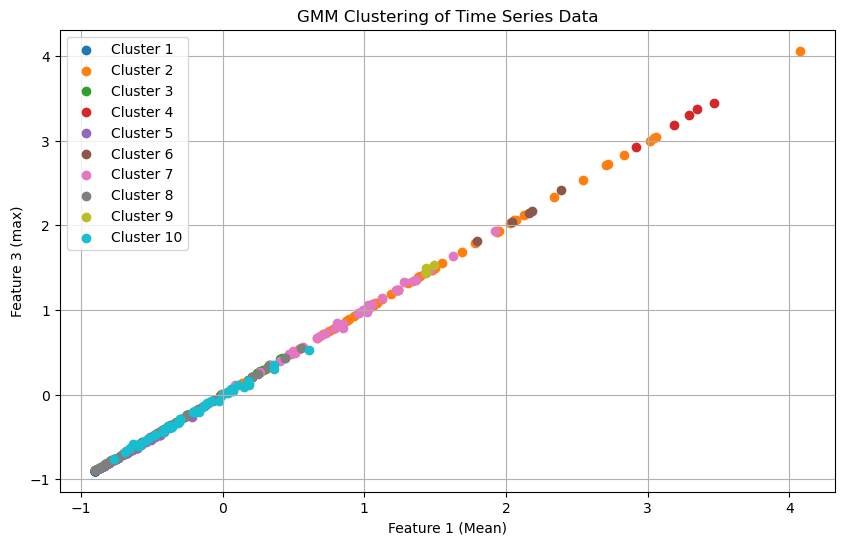

In [45]:
# Plot results
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    plt.scatter(scaled_features[labels == i, 0], scaled_features[labels == i, 2], label=f'Cluster {i+1}')
plt.title("GMM Clustering of Time Series Data")
plt.xlabel("Feature 1 (Mean)")
plt.ylabel("Feature 3 (max)")
plt.legend()
plt.grid()
plt.show()

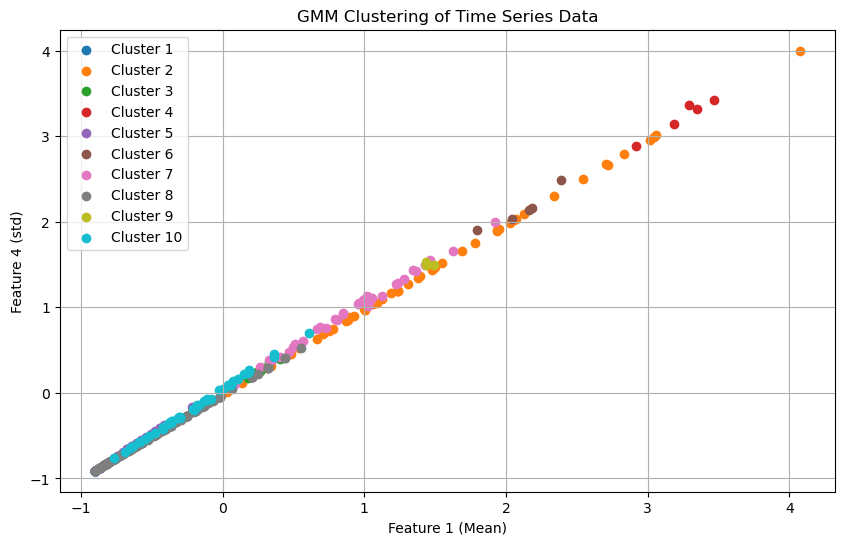

In [46]:
# Plot results
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    plt.scatter(scaled_features[labels == i, 0], scaled_features[labels == i, 3], label=f'Cluster {i+1}')
plt.title("GMM Clustering of Time Series Data")
plt.xlabel("Feature 1 (Mean)")
plt.ylabel("Feature 4 (std)")
plt.legend()
plt.grid()
plt.show()

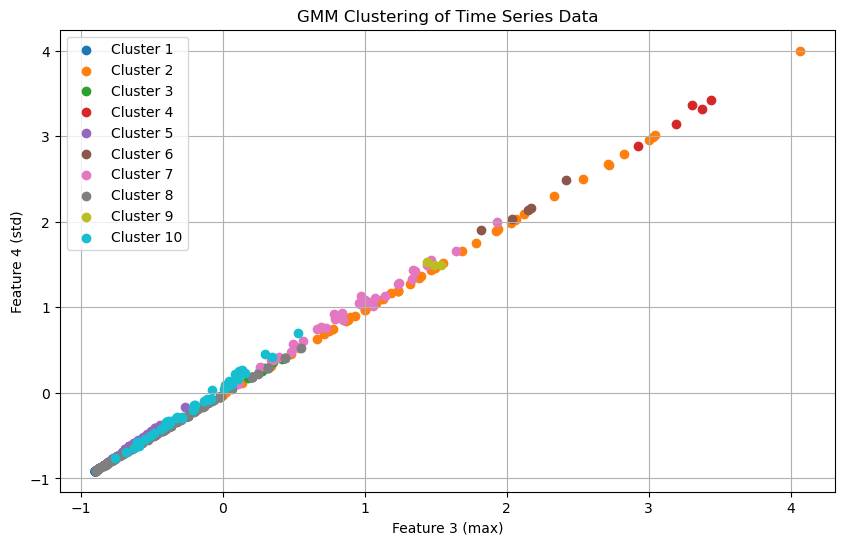

In [47]:
# Plot results
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    plt.scatter(scaled_features[labels == i, 2], scaled_features[labels == i, 3], label=f'Cluster {i+1}')
plt.title("GMM Clustering of Time Series Data")
plt.xlabel("Feature 3 (max)")
plt.ylabel("Feature 4 (std)")
plt.legend()
plt.grid()
plt.show()

In [48]:
qisms_cluster_df = pd.DataFrame({
    "qism_id": qisms_features_df.index,
    "cluster": labels
})

In [49]:
qisms_cluster_df

,qism_id,cluster
0,101,7
1,102,1
2,103,7
3,104,7
4,105,7
...,...,...
369,3505,0
370,3506,0
371,3507,7
372,3508,0


In [50]:
qisms_cluster_df.to_csv("/home/mohamed/Mohamed/Vodafone_project/projects/app/files/anamoly_detection_files/qisms_clusters.csv")

In [51]:
qisms_dfs

{101:                        time  count
 0       2010-01-01 00:00:00    0.0
 1       2010-01-01 00:15:00    0.0
 2       2010-01-01 00:30:00    0.0
 3       2010-01-01 00:45:00    0.0
 4       2010-01-01 01:00:00    4.0
 ...                     ...    ...
 525595  2024-12-30 22:45:00    4.0
 525596  2024-12-30 23:00:00    0.0
 525597  2024-12-30 23:15:00    0.0
 525598  2024-12-30 23:30:00    0.0
 525599  2024-12-30 23:45:00    0.0
 
 [525600 rows x 2 columns],
 102:                        time  count
 0       2010-01-01 00:00:00    0.0
 1       2010-01-01 00:15:00    0.0
 2       2010-01-01 00:30:00    0.0
 3       2010-01-01 00:45:00    0.0
 4       2010-01-01 01:00:00    6.0
 ...                     ...    ...
 525595  2024-12-30 22:45:00    6.0
 525596  2024-12-30 23:00:00    0.0
 525597  2024-12-30 23:15:00    0.0
 525598  2024-12-30 23:30:00    0.0
 525599  2024-12-30 23:45:00    0.0
 
 [525600 rows x 2 columns],
 103:                        time  count
 0       2010-01-01 00:00

In [53]:
clusters_counts = [[] for i in range(10)]
for i, key in enumerate(qisms_dfs.keys()):
    
    cluster = qisms_cluster_df[qisms_cluster_df["qism_id"] == key].cluster.values[0] 
    print(i)
    clusters_counts[cluster].append(qisms_dfs[key]["count"].values)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [55]:
clusters_counts[9]

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 

In [56]:
clusters_counts = list(map(lambda x: np.array(x), clusters_counts))

In [57]:
clusters_counts = list(map(lambda x: x.mean(axis=0), clusters_counts))

In [58]:
clusters_counts = list(map(lambda x: np.rint(x).astype(int), clusters_counts))

In [59]:
len(clusters_counts)

10

In [62]:
import os 

DIR = "./qisms_clusters_dir"
os.makedirs(DIR, exist_ok=True)

for i in range(10):
    df = pd.DataFrame({
        "time": time_column,
        "count": clusters_counts[i]
    })
    df.to_csv(os.path.join(DIR, f"counts_{i}.csv"))